In [1]:
import matplotlib.pyplot as plt
import numpy as np

<div class="alert alert-block alert-success">
<b> </b> 
Convert Head (kJ/kg) vs Flow (ACT_m3/hr) to Pout (barA) vs Flow (kg/hr)
</div>

In [2]:
#------------------------------------------------------
#                    INPUT-23KA502
#------------------------------------------------------

# head_values_list = [
#     [73.08, 69.99, 63.46, 60.03], 
#     [97.14, 96.62, 92.67, 86.48, 75.66, 73.43],
#     [123.08, 122.22, 118.78, 113.11, 104.52, 89.92], 
#     [150.39, 147.99, 143.18, 135.62, 123.08, 107.10],
#     [164.31, 161.56, 156.06, 147.30, 132.35, 116.21]     
# ]

# flow_values_list = [     
#     [1534.41, 1803.50, 2163.01, 2296.48],
#     [1723.85, 1803.50, 2163.01, 2524.67, 2884.17, 2929.38],
#     [2003.71, 2163.01, 2524.67, 2886.32, 3245.83, 3611.79],
#     [2610.77, 2884.17, 3245.83, 3605.33, 3966.99, 4259.76],
#     [2989.65, 3245.83, 3605.33, 3964.84, 4326.49, 4565.45]      
# ]

head_values_list = [
    [74.07, 72.68, 70.11, 66.48, 63.60, 57.53], 
    [97.45, 96.48, 93.49, 88.15, 79.83, 70.14],
    [122.09, 120.48, 116.31, 110.66, 100.32, 86.48], 
    [147.67, 144.36, 139.02, 130.07, 117.51, 104.73],
    [160.09, 155.07, 149.63, 141.22, 127.59, 114.50]
]

flow_values_list = [     
    [1549.588789, 1708.091291, 1929.98812, 2150.495031, 2307.603012, 2497.75838],
    [1746.954935, 1926.13823, 2270.709187, 2638.687846, 2979.066035, 3198.128949],
    [2309.614252, 2535.656675, 2910.540054, 3231.64923, 3584.411272, 3883.377249],
    [3079.045828, 3386.39619, 3697.859929, 4021.690262, 4302.750682, 4479.049435],
    [3532.678224, 3879.984145, 4119.769273, 4363.657423, 4613.002844, 4761.729892]   
]

rpm_values=[6880, 7863, 8846, 9829, 10320]

#----------  INPUT --------------
P_in = 23          # Suction Pressure (barA)
T_in = 273 + 43    # Inlet Temperature (K)
gamma = 1.209      # Heat capacity ratio from unisim
M = 30.2
Zave = 0.87        #suction Z    Zave=0.8587
R = 8.314



#----------Plot adjustmnts--------------------
#plt.title("Comparison: Manufacturer vs. UniSim - 26KA601")
#plt.xlim(40000, 150000)
# xticks = np.arange(40000, 150001, 10000)
# plt.xticks(xticks)
# plt.ylim(30, 140)
# yticks = np.arange(30, 141, 10)
# plt.yticks(yticks)
# plt.grid(True)

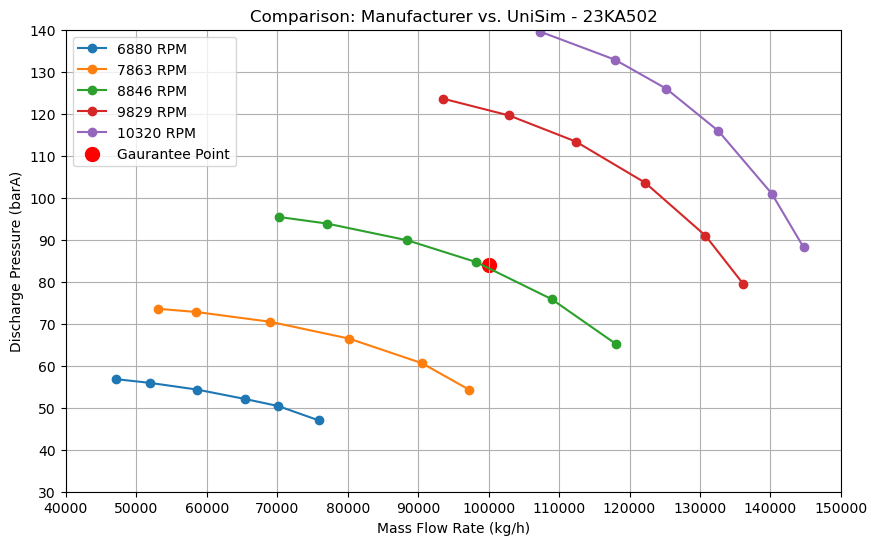

In [3]:
list_of_P_out_values = []
list_of_flow_values = []

    # Compute discharge pressure and standard flow for each set
for head_values, flow_values in zip(head_values_list, flow_values_list):
    ratio = [1 + ((gamma - 1) / gamma) * H * (M/(Zave * R * T_in)) for H in head_values]
    P_out_values = [(P_in) * (r ** ((gamma / (gamma - 1)))) for r in ratio]    
    flow_value_kg_hr = [F*((P_in*100*M)/(R*T_in*Zave)) for F in flow_values]  # P_in is in kPa*100 = bar
    
    list_of_P_out_values.append(P_out_values)
    list_of_flow_values.append(flow_value_kg_hr)
    

# Plot the results
plt.figure(figsize=(10, 6))
plt.xlabel("Mass Flow Rate (kg/h)")
plt.ylabel("Discharge Pressure (barA)")
plt.title("Comparison: Manufacturer vs. UniSim - 23KA502")
plt.xlim(40000, 150000)
xticks = np.arange(40000, 150001, 10000)
plt.xticks(xticks)
plt.ylim(30, 140)
yticks = np.arange(30, 141, 10)
plt.yticks(yticks)
plt.grid(True)


for flow_std, P_out, rpm in zip(list_of_flow_values, list_of_P_out_values, rpm_values):
    plt.plot(flow_std, P_out, marker='o', linestyle='-', label=f"{rpm} RPM")     
    
    plt.legend()
    
plt.scatter(99989, 84, color='red', marker='o', s=100, label="Gaurantee Point")
plt.legend()
    
plt.savefig("23KA502-recompression.png", dpi=300, bbox_inches='tight')

In [4]:
(16.21+63.34)/2

39.775000000000006

In [5]:
(0.9027+0.8148)/2

0.8587499999999999

In [6]:
(66.92+23.32)/2

45.120000000000005

In [7]:
41176.2086223183/23.32

1765.7036287443525

In [8]:
list_of_flow_values[0]

[47090.67213322073,
 51907.427008424704,
 58650.681022661345,
 65351.69662287829,
 70126.07320284675,
 75904.73148459554]

In [9]:
ratio = [1 + ((gamma - 1) / gamma) * H * (M/(Zave * R * T_in))

SyntaxError: incomplete input (684682950.py, line 1)

In [ ]:
list_of_P_out_values[3]

In [ ]:
P_out = 79.53252800449246

In [ ]:
(Zave*R*T_in)/(M*((gamma - 1) / gamma))*((P_out/P_in)**((gamma - 1) / gamma)-1)

In [ ]:
(Zave*R*T_in)/(M*((gamma - 1) / gamma))